# EDA

Сначала проверим исходный датасет перед подготовкой данных.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [2]:
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 50)

In [3]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

raw_path = project_root / "data" / "raw" / "dataset.csv"

raw_path

WindowsPath('C:/Projects/guest-predictor/data/raw/dataset.csv')

In [4]:
raw = pd.read_csv(raw_path, parse_dates=["date"])
raw = raw.sort_values(["restaurant_id", "date"]).reset_index(drop=True)

raw.head()

,date,restaurant_id,guests,revenue
0,2024-01-01,1,65.0,82908.0
1,2024-01-02,1,75.0,128446.0
2,2024-01-03,1,107.0,154598.0
3,2024-01-04,1,113.0,156028.0
4,2024-01-05,1,113.0,166075.0


In [5]:
raw.shape

(2958, 4)

In [6]:
raw.dtypes

date             datetime64[us]
restaurant_id             int64
guests                  float64
revenue                 float64
dtype: object

Видим, что в исходном сыром датасете есть только четыре базовые колонки: дата, идентификатор точки, число гостей и выручка. Количество строк - 2958

In [7]:
summary = pd.DataFrame(
    {
        "rows": [len(raw)],
        "min_date": [raw["date"].min()],
        "max_date": [raw["date"].max()],
        "restaurants": [raw["restaurant_id"].nunique()],
    }
)

summary

,rows,min_date,max_date,restaurants
0,2958,2024-01-01,2026-09-30,3


Видим, что датасет покрывает больше 30 месяцев истории и содержит три ресторана.

In [8]:
duplicates = raw.duplicated(subset=["restaurant_id", "date"]).sum()
duplicates

np.int64(0)

Видим, что дубли отсутствуют

In [9]:
raw.isna().sum()

date              0
restaurant_id     0
guests            9
revenue          12
dtype: int64

Видим, что имеются частично заполненные строки

In [10]:
calendar_gaps = []

for restaurant_id, group in raw.groupby("restaurant_id"):
    full_dates = pd.date_range(group["date"].min(), group["date"].max(), freq="D")
    observed_dates = pd.Index(group["date"])
    missing_dates = full_dates.difference(observed_dates)

    calendar_gaps.append(
        {
            "restaurant_id": restaurant_id,
            "expected_days": len(full_dates),
            "observed_days": len(group),
            "missing_days": len(missing_dates),
        }
    )

calendar_gaps = pd.DataFrame(calendar_gaps)
calendar_gaps

,restaurant_id,expected_days,observed_days,missing_days
0,1,1004,986,18
1,2,1004,986,18
2,3,1004,986,18


Вывод: в raw-датасете есть пропущенные календарные дни.

In [11]:
zero_days = (
    raw.assign(is_zero_day=(raw["guests"].eq(0) & raw["revenue"].eq(0)))
    .groupby("restaurant_id")["is_zero_day"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "zero_days", "mean": "zero_day_share"})
)

zero_days

,zero_days,zero_day_share
restaurant_id,,
1,6,0.006085
2,150,0.152130
3,6,0.006085


Видим, что имеются нулевые дни, которые отличаются от просто пропущенных дат. Их можно интерпретировать как нерабочий день

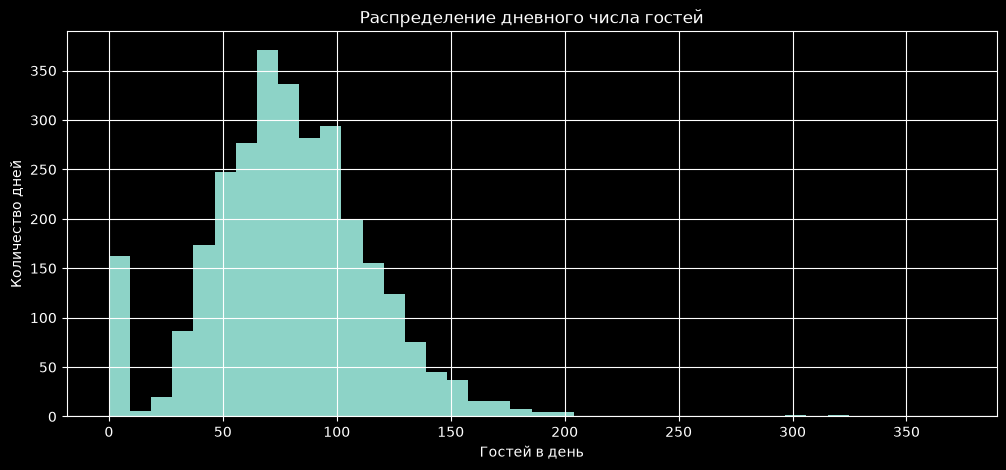

In [12]:
raw["guests"].hist(bins=40)

plt.title("Распределение дневного числа гостей")
plt.xlabel("Гостей в день")
plt.ylabel("Количество дней")
plt.show()

На гистограмме видны типичный дневной поток, нулевые дни и крайние значения. Для оценки модели используем MAE, чтобы измерять ошибку в гостях; при расчёте MAPE нулевые дни нужно исключать.

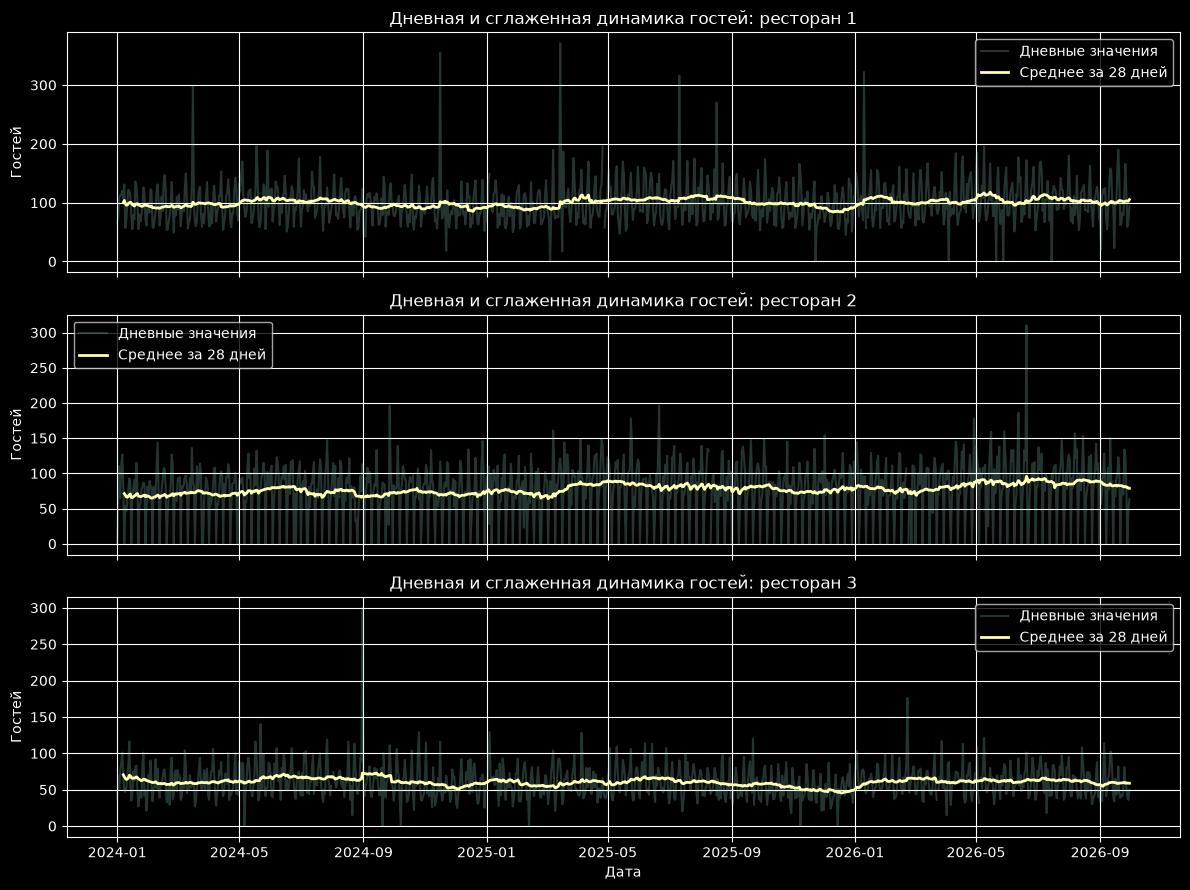

In [13]:
restaurant_ids = sorted(raw["restaurant_id"].unique())

fig, axes = plt.subplots(
    nrows=len(restaurant_ids),
    ncols=1,
    figsize=(12, 3 * len(restaurant_ids)),
    sharex=True,
)

for ax, restaurant_id in zip(axes, restaurant_ids):
    group = raw[raw["restaurant_id"].eq(restaurant_id)].copy()
    group["guests_28d_mean"] = group["guests"].rolling(28, min_periods=7).mean()

    ax.plot(
        group["date"],
        group["guests"],
        alpha=0.25,
        label="Дневные значения",
    )

    ax.plot(
        group["date"],
        group["guests_28d_mean"],
        linewidth=2,
        label="Среднее за 28 дней",
    )

    ax.set_title(f"Дневная и сглаженная динамика гостей: ресторан {restaurant_id}")
    ax.set_ylabel("Гостей")
    ax.legend()

axes[-1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

На графиках видны изменения уровня потока, нулевые дни и отдельные резкие всплески. Для модели используем лаги и скользящие средние, а нулевые дни не считаем пропусками автоматически.

In [14]:
month_stats = raw.copy()
month_stats["month"] = month_stats["date"].dt.month

monthly = (
    month_stats.groupby("month")["guests"]
    .mean()
    .reset_index()
    .sort_values("month")
)

monthly

,month,guests
0,1,78.591912
1,2,74.817814
2,3,80.520147
3,4,80.370229
4,5,85.890110
5,6,83.154717
6,7,83.073529
7,8,81.762774
8,9,77.052239
9,10,74.577778


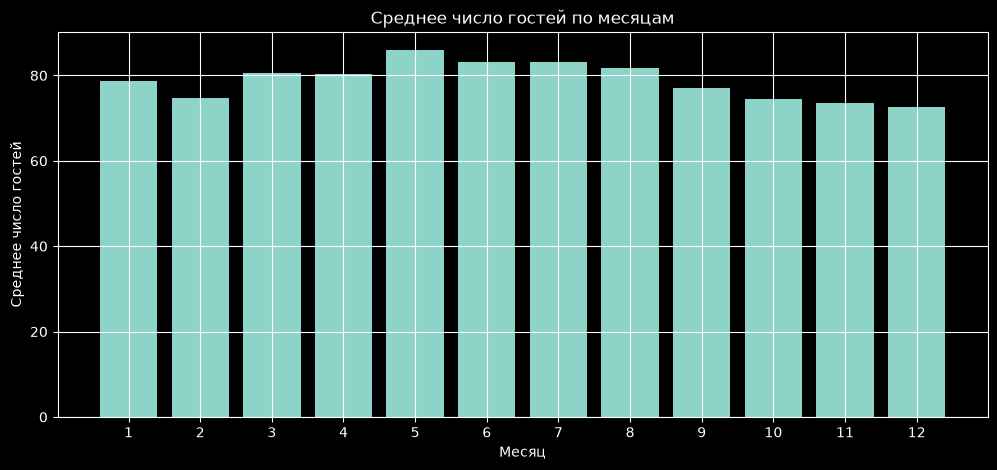

In [15]:
plt.bar(monthly["month"], monthly["guests"])

plt.title("Среднее число гостей по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Среднее число гостей")
plt.xticks(range(1, 13))
plt.show()

Средний поток гостей меняется по месяцам. Поэтому добавляем признак месяца, чтобы модель могла учитывать годовую сезонность.

In [16]:
dow_stats = raw.copy()
dow_stats["dow"] = dow_stats["date"].dt.dayofweek
dow_stats["dow_name"] = dow_stats["date"].dt.day_name()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly = (
    dow_stats.groupby(["dow", "dow_name"])["guests"]
    .mean()
    .reset_index()
    .sort_values("dow")
)

weekly

,dow,dow_name,guests
0,0,Monday,36.576471
1,1,Tuesday,63.021429
2,2,Wednesday,73.544811
3,3,Thursday,81.817102
4,4,Friday,100.514151
5,5,Saturday,114.026253
6,6,Sunday,86.394231


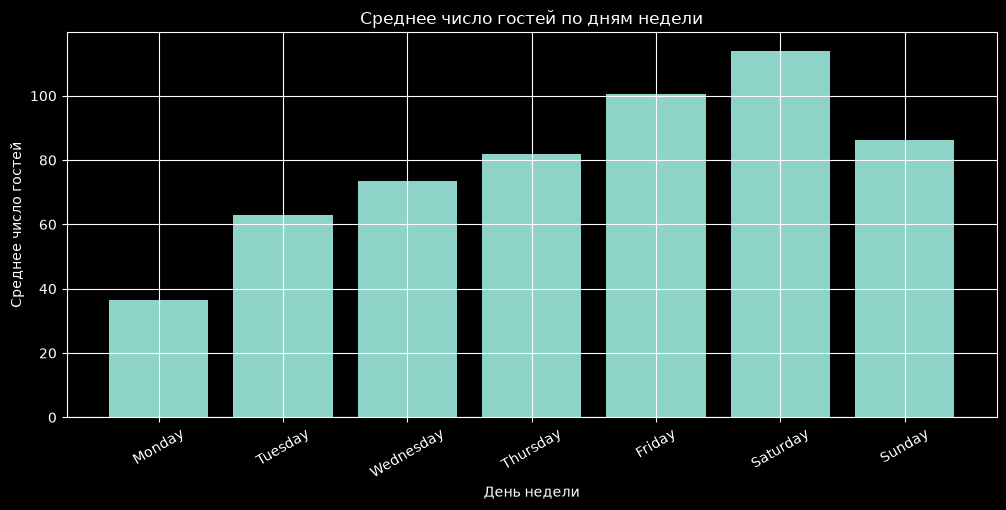

In [17]:
plt.bar(weekly["dow_name"], weekly["guests"])

plt.title("Среднее число гостей по дням недели")
plt.xlabel("День недели")
plt.ylabel("Среднее число гостей")
plt.xticks(rotation=30)
plt.show()

Как видим, недельная сезонность важна для модели, потому что поток гостей заметно зависит от дня недели

In [18]:
outlier_rows = []

for restaurant_id, group in raw.groupby("restaurant_id"):
    q1 = group["guests"].quantile(0.25)
    q3 = group["guests"].quantile(0.75)
    iqr = q3 - q1

    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr

    count = group["guests"].lt(lower).sum() + group["guests"].gt(upper).sum()

    outlier_rows.append(
        {
            "restaurant_id": restaurant_id,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_days": count,
        }
    )

outliers = pd.DataFrame(outlier_rows)
outliers

,restaurant_id,lower_bound,upper_bound,outlier_days
0,1,14.0,182.0,21
1,2,7.0,159.0,158
2,3,3.0,115.0,20


Видим, что встречаются экстремальные значения. Часть может быть реальными событиями, а часть — аномалиями. На этапе подготовки данных их нужно обработать

### Проверка processed-датасета

Теперь посмотрим, что изменилось после подготовки данных.

In [19]:
processed_path = project_root / "data" / "processed" / "dataset.csv"

processed = pd.read_csv(processed_path, parse_dates=["date"])
processed = processed.sort_values(["restaurant_id", "date"]).reset_index(drop=True)

processed.head()

,date,restaurant_id,guests,revenue
0,2024-01-01,1,65,82908.0
1,2024-01-02,1,75,128446.0
2,2024-01-03,1,107,154598.0
3,2024-01-04,1,113,156028.0
4,2024-01-05,1,113,166075.0


In [20]:
processed.shape, processed.columns.tolist()

((3012, 4), ['date', 'restaurant_id', 'guests', 'revenue'])

In [21]:
processed.isna().sum()

date             0
restaurant_id    0
guests           0
revenue          0
dtype: int64

In [22]:
processed.dtypes

date             datetime64[us]
restaurant_id             int64
guests                    int64
revenue                 float64
dtype: object

Видим, что после подготовки в датасете остались только базовые колонки, а пропущенных значений больше нет.

In [23]:
processed_calendar_check = []

for restaurant_id, group in processed.groupby("restaurant_id"):
    full_dates = pd.date_range(group["date"].min(), group["date"].max(), freq="D")
    observed_dates = pd.Index(group["date"])
    missing_dates = full_dates.difference(observed_dates)

    processed_calendar_check.append(
        {
            "restaurant_id": restaurant_id,
            "expected_days": len(full_dates),
            "observed_days": len(group),
            "missing_days": len(missing_dates),
        }
    )

processed_calendar_check = pd.DataFrame(processed_calendar_check)
processed_calendar_check

,restaurant_id,expected_days,observed_days,missing_days
0,1,1004,1004,0
1,2,1004,1004,0
2,3,1004,1004,0


После восстановления календаря у каждого ресторана получился непрерывный дневной ряд.

In [24]:
comparison = (
    raw.groupby("restaurant_id")
    .size()
    .rename("raw_rows")
    .to_frame()
    .join(
        processed.groupby("restaurant_id")
        .size()
        .rename("processed_rows")
    )
)

comparison["restored_rows"] = comparison["processed_rows"] - comparison["raw_rows"]

comparison

,raw_rows,processed_rows,restored_rows
restaurant_id,,,
1,986,1004,18
2,986,1004,18
3,986,1004,18


Строк стало больше, потому что пропущенные календарные дни были восстановлены.

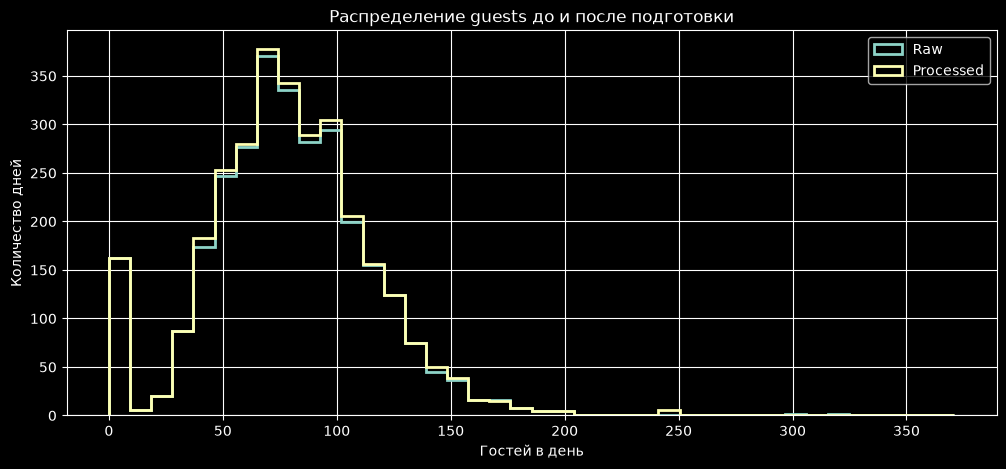

In [25]:
values = pd.concat(
    [
        raw["guests"].dropna(),
        processed["guests"],
    ],
    ignore_index=True,
)

bins = np.linspace(values.min(), values.max(), 41)

plt.hist(
    raw["guests"].dropna(),
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Raw",
)

plt.hist(
    processed["guests"],
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Processed",
)

plt.title("Распределение guests до и после подготовки")
plt.xlabel("Гостей в день")
plt.ylabel("Количество дней")
plt.legend()
plt.show()

После подготовки пропуски заполнены, а общий вид распределения числа гостей сохранился. Это важно для модели: обработка данных не должна убирать обычные колебания потока вместе с выбросами.

In [26]:
pd.DataFrame(
    {
        "raw_guests_max": raw.groupby("restaurant_id")["guests"].max(),
        "processed_guests_max": processed.groupby("restaurant_id")["guests"].max(),
        "raw_revenue_max": raw.groupby("restaurant_id")["revenue"].max(),
        "processed_revenue_max": processed.groupby("restaurant_id")["revenue"].max(),
    }
)

,raw_guests_max,processed_guests_max,raw_revenue_max,processed_revenue_max
restaurant_id,,,,
1,371.0,245,659590.0,412652.00
2,310.0,216,377531.0,282799.50
3,300.0,154,624867.0,295852.75


Видим, что экстремальные значения после подготовки стали ниже или остались прежними, потому что выбросы были ограничены